In [1]:
from lightweaver.fal import Falc82
from lightweaver.rh_atoms import H_6_atom, H_6_CRD_atom, H_3_atom, C_atom, O_atom, OI_ord_atom, \
                                 Si_atom, Al_atom, CaII_atom, Fe_atom, FeI_atom, He_9_atom, \
                                 He_atom, He_large_atom, MgII_atom, N_atom, Na_atom, S_atom
import lightweaver as lw
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
from scipy.interpolate import interpn
import astropy
import os
import torch
import time

In [2]:
nx, ny, nz = 504, 504, 425
nlev = 6
datadir = '/dat/andreuva/gpu/graphnet/data_porta'

In [3]:
geometry_file = "/dat/andreuva/gpu/graphnet/en024048_hion/grid_bifrost.npz"
geometry_grid = np.load(geometry_file)["z"]

In [4]:
# ---- memory–mapped arrays ----
pops = np.memmap(f'{datadir}/AR_385_CaII_5L_pops.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, nlev))
b_xyz = np.memmap(f'{datadir}/AR_385_B.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
temp = np.memmap(f'{datadir}/AR_385_temp.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
vel = np.memmap(f'{datadir}/AR_385_veloc.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
n_e = np.memmap(f'{datadir}/AR_385_ne.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
n_h = np.memmap(f'{datadir}/AR_385_nh.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
n_p = np.memmap(f'{datadir}/AR_385_np.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))

In [5]:
nwave = 1001
wave = np.linspace(853.9444, 854.9444, nwave)
I_lte, I_nlte, I_target = np.zeros((nwave)), np.zeros((nwave)), np.zeros((nwave))

col_pix = 234
row_pix = 234

In [6]:
def synth_8542(atmos, conserve, useNe, wave):
    '''
    Synthesise a spectral line for given atmosphere with different
    conditions.

    Parameters
    ----------
    atmos : lw.Atmosphere
        The atmospheric model in which to synthesise the line.
    conserve : bool
        Whether to start from LTE electron density and conserve charge, or
        simply use from the electron density present in the atomic model.
    useNe : bool
        Whether to use the electron density present in the model as the
        starting solution, or compute the LTE electron density.
    wave : np.ndarray
        Array of wavelengths over which to resynthesise the final line
        profile for muz=1.

    Returns
    -------
    ctx : lw.Context
        The Context object that was used to compute the equilibrium
        populations.
    Iwave : np.ndarray
        The intensity at muz=1 for each wavelength in `wave`.
    '''
    # Configure the atmospheric angular quadrature
    atmos.quadrature(5)
    # Configure the set of atomic models to use.
    aSet = lw.RadiativeSet([H_6_atom(), C_atom(), O_atom(), Si_atom(),
                            Al_atom(), CaII_atom(), Fe_atom(), He_9_atom(),
                            MgII_atom(), N_atom(), Na_atom(), S_atom()
                           ])
    # Set H and Ca to "active" i.e. NLTE, everything else participates as an
    # LTE background.
    aSet.set_active('H', 'Ca')
    # Compute the necessary wavelength dependent information (SpectrumConfiguration).
    spect = aSet.compute_wavelength_grid()

    # Either compute the equilibrium populations at the fixed electron density
    # provided in the model, or iterate an LTE electron density and compute the
    # corresponding equilibrium populations (SpeciesStateTable).
    if useNe:
        eqPops = aSet.compute_eq_pops(atmos)
    else:
        eqPops = aSet.iterate_lte_ne_eq_pops(atmos)

    # Configure the Context which holds the state of the simulation for the
    # backend, and provides the python interface to the backend.
    # Feel free to increase Nthreads to increase the number of threads the
    # program will use.
    ctx = lw.Context(atmos, spect, eqPops, conserveCharge=conserve, Nthreads=1)
    # Iterate the Context to convergence (using the iteration function now
    # provided by Lightweaver)
    lw.iterate_ctx_se(ctx)
    # Update the background populations based on the converged solution and
    # compute the final intensity for mu=1 on the provided wavelength grid.
    eqPops.update_lte_atoms_Hmin_pops(atmos)
    Iwave = ctx.compute_rays(wave, [atmos.muz[-1]], stokes=False)
    return ctx, eqPops, Iwave

In [7]:
# Falc82 atmosphere NLTE Calculations
atmosRef = Falc82()
ctx_lw_nlte, eqPops_lw_nlte, I_lw_nlte = synth_8542(atmosRef, conserve=False, useNe=True, wave=wave)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 7:
dJ = 1.43e+00
    H delta = 4.1087e-01
    Ca delta = 2.6971e-01
-- Iteration 14:
dJ = 2.32e-01
    H delta = 1.3887e-01
    Ca delta = 1.1538e-01
-- Iteration 22:
dJ = 1.07e-01
    H delta = 5.5150e-02
    Ca delta = 4.8401e-02
-- Iteration 28:
dJ = 8.26e-02
    H delta = 4.9588e-02
    Ca delta = 3.2670e-02
-- Iteration 36:
dJ = 7.28e-02
    H delta = 4.3635e-02
    Ca delta = 2.3167e-02
-- Iteration 42:
dJ = 6.66e-02
    H delta = 3.7502e-02
    Ca delta = 1.8113e-02
-- Iteration 50:
dJ = 5.66e-02
    H delta = 2.9194e-02
    Ca delta = 1.2302e-02
-- Iteration 57:
dJ = 4.50e-02
    H delta = 2.3252e-02
    Ca delta = 8.0495e-03
-- Iteration 64:
dJ = 3.12e-02
    H delta = 1.7068e-02
    Ca delta = 4.7171e-03
-- Iteration 70:
dJ = 2.09e-02
    H delta = 1.1711e-02
    Ca delta = 2.8660e-03
-- Iteration 79:
dJ = 9.93e-03
    H delta = 5.6974e-03
    Ca delta = 1.2513e-03
-- Iteration 85:
dJ = 5.74e-03
    

In [8]:
z_shift = 51

In [9]:
# Note: We slice at [row_pix] fixed, iterating [col_pix]
temp_atm = np.ascontiguousarray(temp[:z_shift-1:-1, col_pix, row_pix, 0].astype(np.float64))
b_xyz_atm = np.ascontiguousarray(b_xyz[:z_shift-1:-1, col_pix, row_pix, 2].astype(np.float64))
vel_atm = np.ascontiguousarray(vel[:z_shift-1:-1, col_pix, row_pix, 2].astype(np.float64))/1e2
n_e_atm = np.ascontiguousarray(n_e[:z_shift-1:-1, col_pix, row_pix, 0].astype(np.float64))*1e6
n_h_atm = np.ascontiguousarray(n_h[:z_shift-1:-1, col_pix, row_pix, 0].astype(np.float64))*1e6
n_p_atm = np.ascontiguousarray(n_p[:z_shift-1:-1, col_pix, row_pix, 0].astype(np.float64))*1e6
pops_atm = np.ascontiguousarray(pops[-(z_shift+1)::-1, col_pix, row_pix, :].astype(np.float64))*1e6
z_atm = np.ascontiguousarray(geometry_grid[:z_shift-1:-1].astype(np.float64))*1e6
# set z_atm to astropy units in m
z_atm = astropy.units.Quantity(z_atm, astropy.units.m)

useful_atm_slice = slice(100+z_shift, 400+z_shift, 3)

temp_atm = np.ascontiguousarray(temp_atm[useful_atm_slice].astype(np.float64))
b_xyz_atm = np.ascontiguousarray(b_xyz_atm[useful_atm_slice].astype(np.float64))
vel_atm = np.ascontiguousarray(vel_atm[useful_atm_slice].astype(np.float64))
n_e_atm = np.ascontiguousarray(n_e_atm[useful_atm_slice].astype(np.float64))
n_h_atm = np.ascontiguousarray(n_h_atm[useful_atm_slice].astype(np.float64))
n_p_atm = np.ascontiguousarray(n_p_atm[useful_atm_slice].astype(np.float64))
pops_atm = np.ascontiguousarray(pops_atm[useful_atm_slice].astype(np.float64))
z_atm = np.ascontiguousarray(z_atm[useful_atm_slice].astype(np.float64))

useful_atm_slice = slice(None, None, 1)

# --- Plotting atmosphere parameters ---
# Assuming Lightweaver standard units (CGS)
z_falc_m = atmosRef.z               # m
temp_falc = atmosRef.temperature    # K
vlos_falc = atmosRef.vlos           # cm/s (typically 0 for FALC)
nh_falc = atmosRef.nHTot            # cm^-3
ne_falc = atmosRef.ne               # cm^-3

Loaded geometry grid from /dat/andreuva/gpu/graphnet/en024048_hion/grid_bifrost.npz with shape (75,).


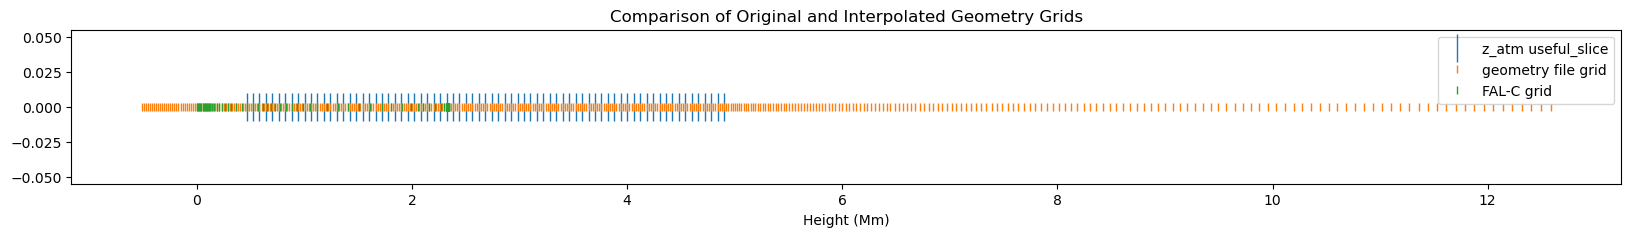

In [10]:
print(f"Loaded geometry grid from {geometry_file} with shape {z_atm.shape}.")
plt.figure(figsize=(20, 2))
plt.plot(z_atm[useful_atm_slice]/1e6, z_atm[useful_atm_slice] * 0, '|', markersize=20, label='z_atm useful_slice')
plt.plot(geometry_grid, geometry_grid * 0, '|', label='geometry file grid')
plt.plot(atmosRef.z/1e6, atmosRef.z * 0, '|', label='FAL-C grid')
plt.xlabel('Height (Mm)')
plt.legend()
plt.title('Comparison of Original and Interpolated Geometry Grids')
plt.show()
# plt.close()

In [11]:
atmos_lte = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, 
                                depthScale=z_atm[useful_atm_slice], 
                                temperature=temp_atm[useful_atm_slice],
                                nHTot=n_h_atm[useful_atm_slice],
                                ne=n_e_atm[useful_atm_slice],
                                vturb=0e4*np.ones_like(temp_atm[useful_atm_slice]),
                                vlos=vel_atm[useful_atm_slice])
ctx_lte, eqPops_lte, I_lte = synth_8542(atmos_lte, conserve=False, useNe=False, wave=wave)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 10:
dJ = 1.68e+00
    H delta = 4.2607e-01
    Ca delta = 2.9250e-01
-- Iteration 17:
dJ = 2.45e-01
    H delta = 9.5157e-02
    Ca delta = 7.7352e-02
-- Iteration 24:
dJ = 3.70e-02
    H delta = 2.7960e-02
    Ca delta = 2.6075e-02
-- Iteration 33:
dJ = 1.10e-02
    H delta = 6.6684e-03
    Ca delta = 5.3713e-03
-- Iteration 43:
dJ = 1.78e-03
    H delta = 1.4959e-03
    Ca delta = 7.7019e-04
--------------------------------------------------------------------------------
Final Iteration: 46
--------------------------------------------------------------------------------
dJ = 1.13e-03
    H delta = 9.5426e-04
    Ca delta = 4.4251e-04
--------------------------------------------------------------------------------
Context converged to statistical equilibrium in 46 iterations after 1.21 s.
--------------------------------------------------------------------------------
LTE Iterations 1 (He slowest convergence)

In [12]:
atmos_nlte = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, 
                                depthScale=z_atm[useful_atm_slice],
                                temperature=temp_atm[useful_atm_slice],
                                nHTot=n_h_atm[useful_atm_slice],
                                ne=n_e_atm[useful_atm_slice],
                                vturb=0e4*np.ones_like(temp_atm[useful_atm_slice]),
                                vlos=vel_atm[useful_atm_slice])
ctx_nlte, eqPops_nlte, I_nlte = synth_8542(atmos_nlte, conserve=True, useNe=True, wave=wave)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 9:
dJ = 2.11e+00
    H delta = 6.7328e-01
    Ca delta = 3.4927e-01
    ne delta = 3.6690e-09
-- Iteration 16:
dJ = 4.33e-01
    H delta = 2.4223e-01
    Ca delta = 1.4088e-01
    ne delta = 1.1655e-09
-- Iteration 25:
dJ = 6.31e-02
    H delta = 5.1236e-02
    Ca delta = 1.4227e-02
    ne delta = 8.0331e-10
-- Iteration 33:
dJ = 1.10e-02
    H delta = 8.7558e-03
    Ca delta = 3.7499e-03
    ne delta = 1.8082e-10
-- Iteration 41:
dJ = 1.88e-03
    H delta = 1.5111e-03
    Ca delta = 8.6093e-04
    ne delta = 3.4327e-11
--------------------------------------------------------------------------------
Final Iteration: 43
--------------------------------------------------------------------------------
dJ = 1.22e-03
    H delta = 9.8411e-04
    Ca delta = 5.8224e-04
    ne delta = 2.2476e-11
--------------------------------------------------------------------------------
Context converged to statistical equilibriu

In [13]:
atmos_target = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, 
                                    depthScale=z_atm[useful_atm_slice], 
                                    temperature=temp_atm[useful_atm_slice],
                                    nHTot=n_h_atm[useful_atm_slice],
                                    ne=n_e_atm[useful_atm_slice],
                                    vturb=0e4*np.ones_like(temp_atm[useful_atm_slice]),
                                    vlos=vel_atm[useful_atm_slice])

ctx_target, eqPops_target, I_target = synth_8542(atmos_target, conserve=False, useNe=True, wave=wave)
eqPops_target.atomicPops['Ca'].n = np.ascontiguousarray(np.moveaxis(pops_atm[useful_atm_slice, :], 1, 0))
I_target = ctx_target.compute_rays(wave, [atmos_target.muz[-1]], stokes=False)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 8:
dJ = 1.80e+00
    H delta = 9.1093e-01
    Ca delta = 3.0844e-01
-- Iteration 18:
dJ = 4.85e-01
    H delta = 2.1238e-01
    Ca delta = 9.5470e-02
-- Iteration 26:
dJ = 3.38e-02
    H delta = 2.6712e-02
    Ca delta = 5.8117e-03
-- Iteration 35:
dJ = 4.23e-03
    H delta = 3.3804e-03
    Ca delta = 6.8309e-04
--------------------------------------------------------------------------------
Final Iteration: 41
--------------------------------------------------------------------------------
dJ = 1.13e-03
    H delta = 9.1206e-04
    Ca delta = 1.7801e-04
--------------------------------------------------------------------------------
Context converged to statistical equilibrium in 41 iterations after 1.00 s.
--------------------------------------------------------------------------------
LTE Iterations 1 (-- slowest convergence)


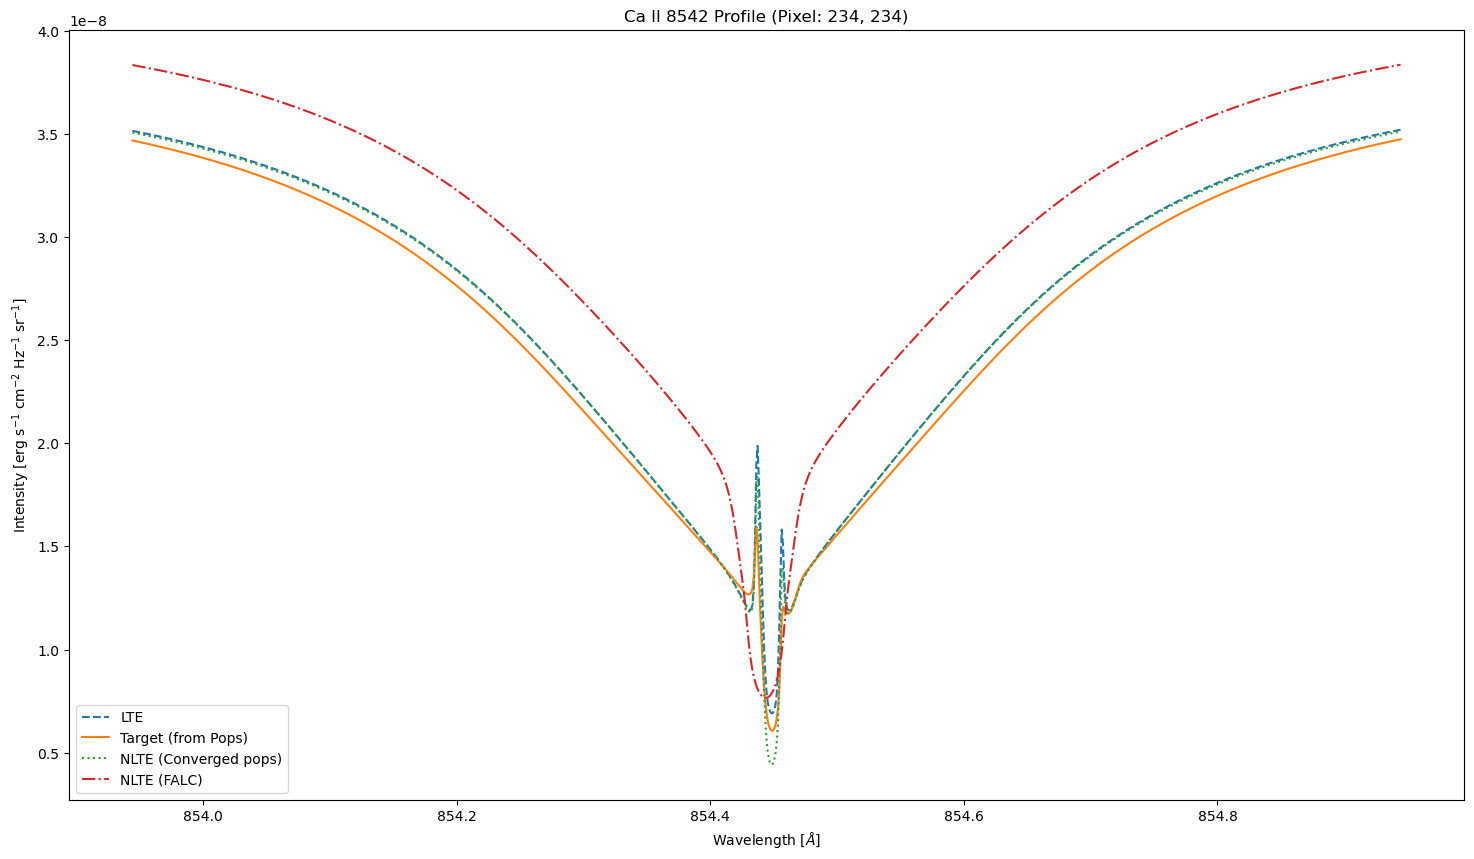

In [14]:
# --- Plotting profiles ---
fig, ax = plt.subplots(figsize=(18, 10))

# Plot intensity
ax.plot(wave, I_lte, label='LTE', color='C0', linestyle='--')
ax.plot(wave, I_target, label='Target (from Pops)', color='C1')
ax.plot(wave, I_nlte, label='NLTE (Converged pops)', color='C2', linestyle=':')
ax.plot(wave, I_lw_nlte, label='NLTE (FALC)', color='C3', linestyle='-.')

# Formatting
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$ sr$^{-1}$]')
ax.set_title(f'Ca II 8542 Profile (Pixel: {col_pix}, {row_pix})')
ax.legend()

plt.show()

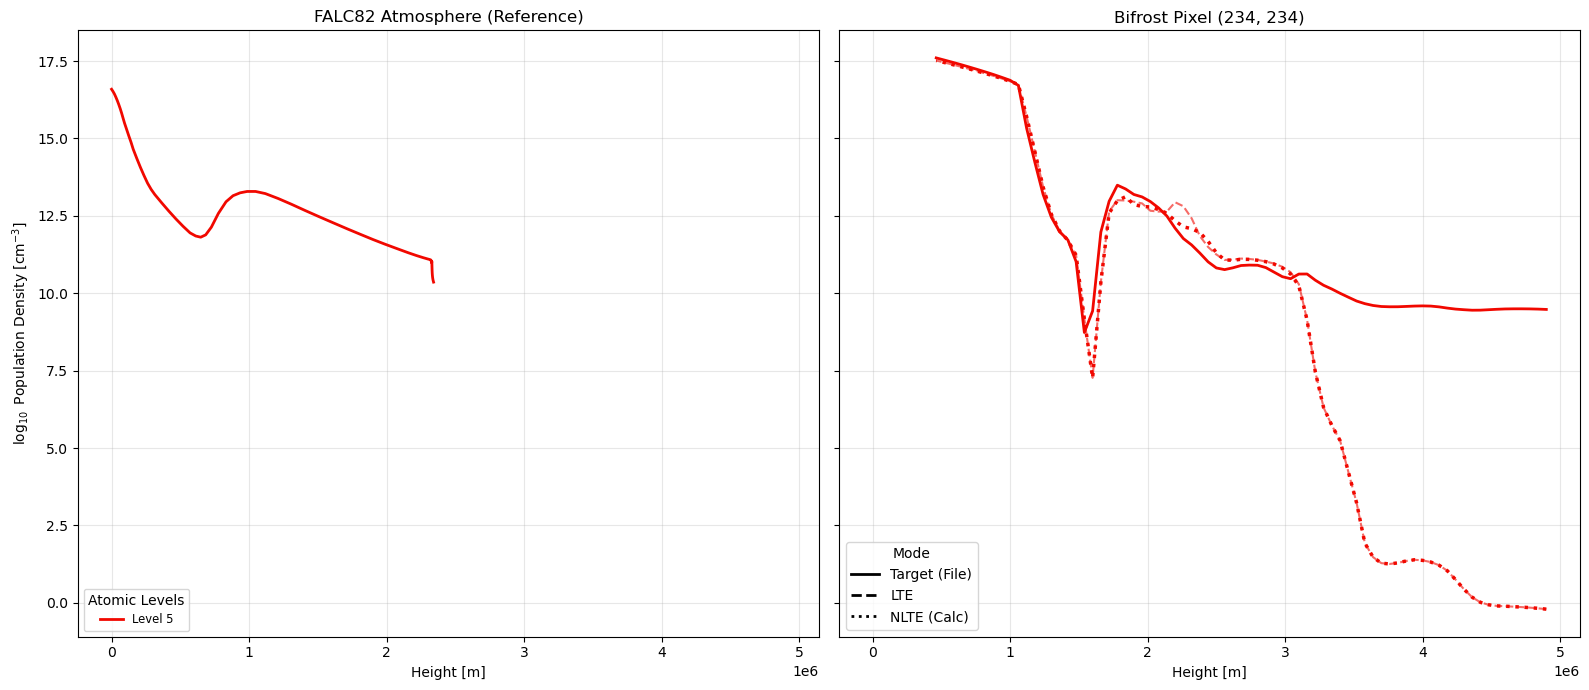

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
# Define colors for different levels
colors = plt.cm.jet(np.linspace(0, 0.9, nlev))
# --- Subplot 1: FALC82 Atmosphere (atmosRef) ---
ax1 = axes[0]

levels = [5] # np.arange(nlev)
for i in levels:
    # Plot NLTE populations for FALC
    ax1.plot(z_falc_m, np.log10(eqPops_lw_nlte.atomicPops['Ca'].n[i, :]), 
             color=colors[i], linestyle='-', linewidth=2, label=f'Level {i}')

ax1.set_title("FALC82 Atmosphere (Reference)")
ax1.set_xlabel("Height [m]")
ax1.set_ylabel(r"$\log_{10}$ Population Density [cm$^{-3}$]")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left', ncol=2, fontsize='small', title='Atomic Levels')

# --- Subplot 2: Bifrost Pixel Atmospheres ---
ax2 = axes[1]

for i in levels:
    # LTE Populations (Dashed)
    ax2.plot(z_atm[useful_atm_slice], np.log10(eqPops_lte.atomicPops['Ca'].n[i, :]), 
             color=colors[i], linestyle='--', alpha=0.6)
    
    # Target Populations (Solid)
    ax2.plot(z_atm[useful_atm_slice], np.log10(eqPops_target.atomicPops['Ca'].n[i, :]), 
             color=colors[i], linestyle='-', linewidth=2)
    
    # NLTE Populations (Dotted)
    ax2.plot(z_atm[useful_atm_slice], np.log10(eqPops_nlte.atomicPops['Ca'].n[i, :]), 
             color=colors[i], linestyle=':', linewidth=2.5)

# Create legend for calculation modes in the second plot
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='k', lw=2, linestyle='-'),
                Line2D([0], [0], color='k', lw=2, linestyle='--'),
                Line2D([0], [0], color='k', lw=2, linestyle=':')]

ax2.legend(custom_lines, ['Target (File)', 'LTE', 'NLTE (Calc)'], loc='lower left', title='Mode')
ax2.set_title(f"Bifrost Pixel ({col_pix}, {row_pix})")
ax2.set_xlabel("Height [m]")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

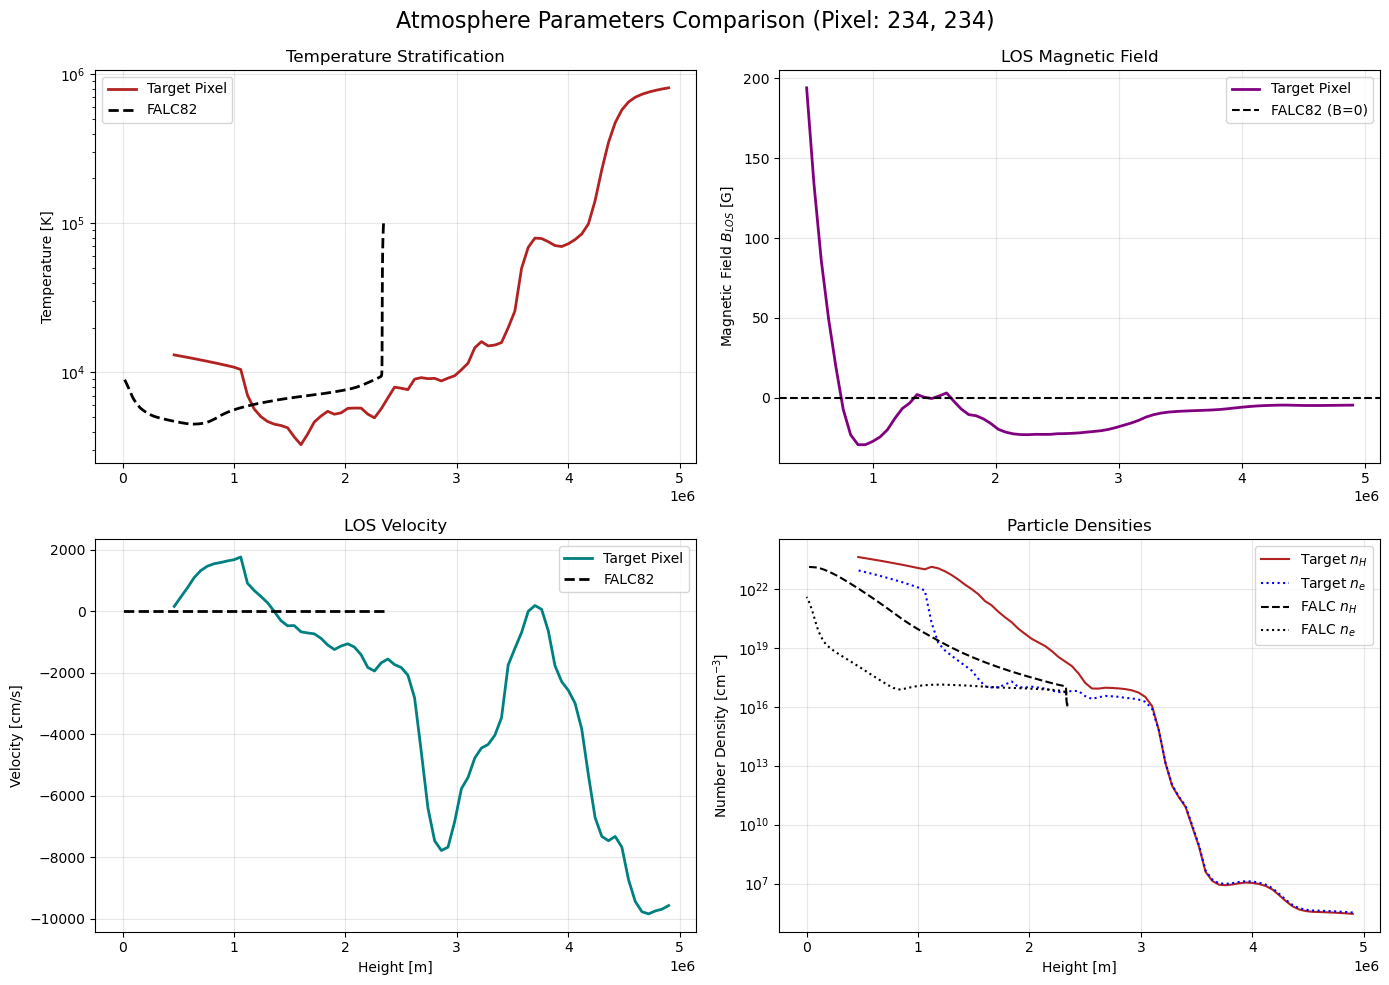

In [16]:
# --- Create Plot ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Temperature ---
axs[0, 0].plot(z_atm[useful_atm_slice], temp_atm[useful_atm_slice], color='firebrick', linewidth=2, label='Target Pixel')
axs[0, 0].plot(z_falc_m, temp_falc, color='black', linestyle='--', linewidth=2, label='FALC82')
axs[0, 0].set_ylabel('Temperature [K]')
axs[0, 0].set_title('Temperature Stratification')
axs[0, 0].legend()
axs[0, 0].set_yscale('log')
axs[0, 0].grid(True, alpha=0.3)

# --- Panel 2: Magnetic Field (LOS) ---
axs[0, 1].plot(z_atm[useful_atm_slice], b_xyz_atm[useful_atm_slice], color='purple', linewidth=2, label='Target Pixel')
axs[0, 1].axhline(0, color='black', linestyle='--', linewidth=1.5, label='FALC82 (B=0)')
axs[0, 1].set_ylabel('Magnetic Field $B_{LOS}$ [G]')
axs[0, 1].set_title('LOS Magnetic Field')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Panel 3: Velocity (LOS) ---
axs[1, 0].plot(z_atm[useful_atm_slice], vel_atm[useful_atm_slice], color='teal', linewidth=2, label='Target Pixel')
axs[1, 0].plot(z_falc_m, vlos_falc, color='black', linestyle='--', linewidth=2, label='FALC82')
axs[1, 0].set_ylabel('Velocity [cm/s]')
axs[1, 0].set_xlabel('Height [m]')
axs[1, 0].set_title('LOS Velocity')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Panel 4: Number Densities ---
# Target
axs[1, 1].plot(z_atm[useful_atm_slice], n_h_atm[useful_atm_slice], label=r'Target $n_H$', color='firebrick')
axs[1, 1].plot(z_atm[useful_atm_slice], n_e_atm[useful_atm_slice], label=r'Target $n_e$', color='blue', linestyle=':')
# FALC
axs[1, 1].plot(z_falc_m, nh_falc, label=r'FALC $n_H$', color='black', linestyle='--')
axs[1, 1].plot(z_falc_m, ne_falc, label=r'FALC $n_e$', color='black', linestyle=':')

axs[1, 1].set_yscale('log')
axs[1, 1].set_ylabel(r'Number Density [cm$^{-3}$]')
axs[1, 1].set_xlabel('Height [m]')
axs[1, 1].set_title('Particle Densities')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3, which='both')

plt.suptitle(f'Atmosphere Parameters Comparison (Pixel: {col_pix}, {row_pix})', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()